# Customer Churn Analysis - Week 1 EDA
**Author**: [Haseeb Bilal]
**Date**: [4/03/2026]
**Course**: Introduction to Applied AI
## Project Overview
This notebook performs exploratory data analysis on customer churn data to identify
patterns and inform our predictive modeling approach.
## Table of Contents
1. Dataset Overview
2. Numerical Features Analysis
3. Categorical Features Analysis
4. Feature Correlations
5. Key Insights and Findings

In [16]:
# Data manipulation
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline
print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/sheikhhaseeb123/churn-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# First look
print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

## 1. Dataset Overview

In [ ]:
# 1.1 Column names and types
print('Column Information:')
df.info()

In [8]:
# 1.2 Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# 1.3 Check for missing values
print('Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0])
# Fix TotalCharges if needed
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Missing Values:
Series([], dtype: int64)


In [10]:
# 1.4 Target variable distribution
print('Churn Distribution:')
print(df['Churn'].value_counts())
print('\nChurn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


# Key Findings:- Dataset has X customers- Churn rate is Y%- Z missing values in TotalCharges column- Features include demographics, services, and account info

## 2. Numerical Features Analysis

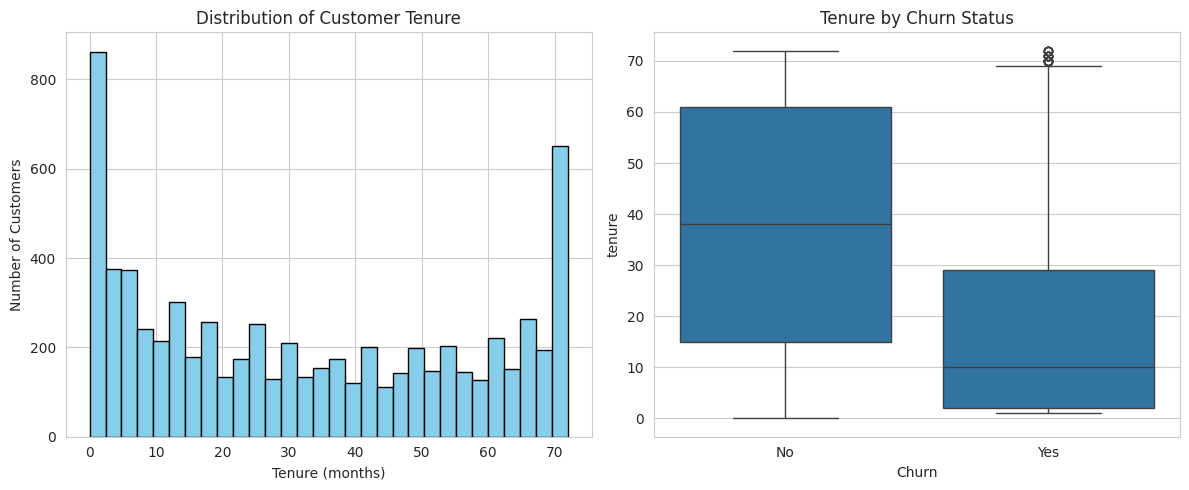

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure')
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')
plt.tight_layout()
plt.show()

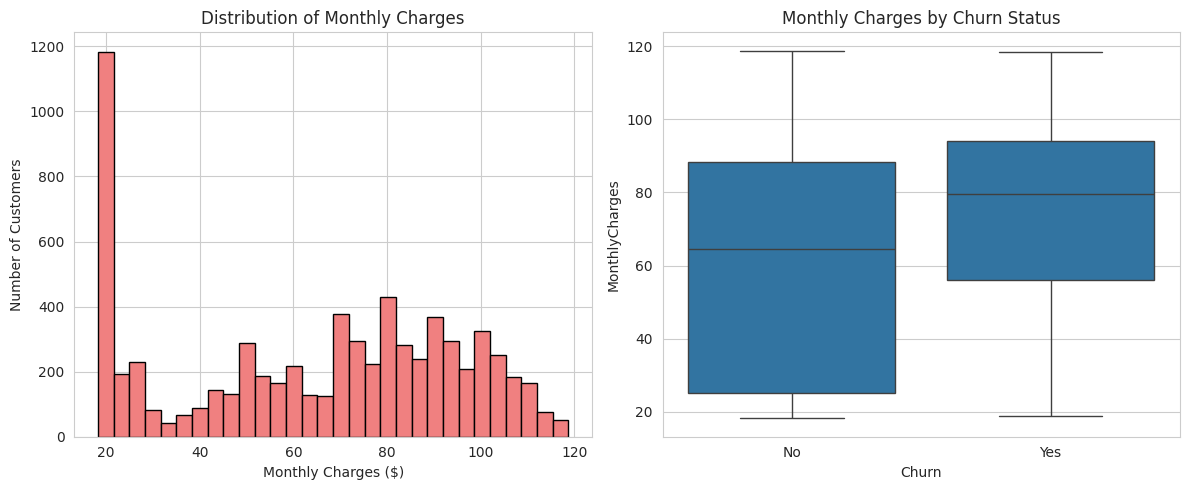

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges')
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show()

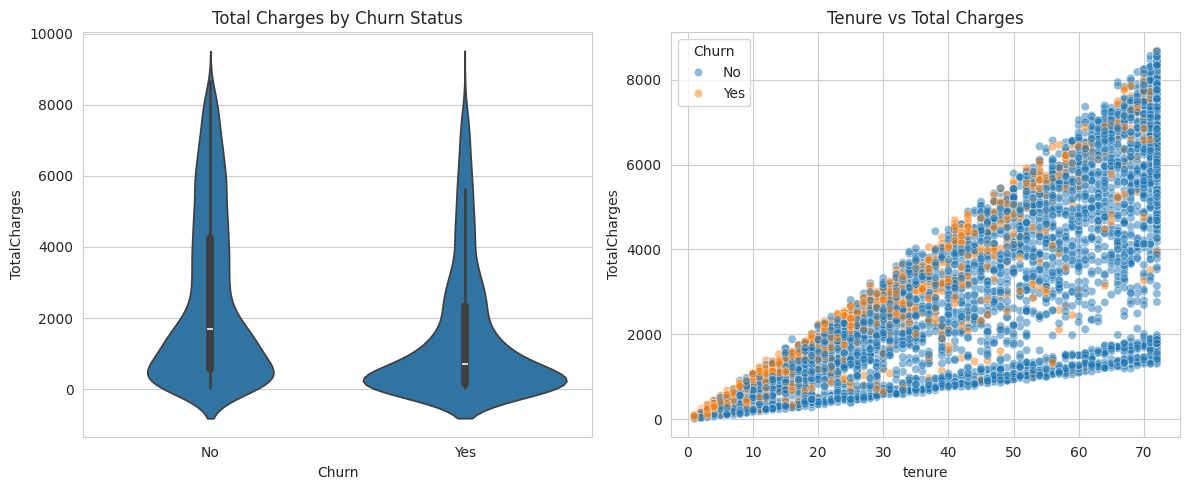

In [13]:
# Remove missing values for this plot
df_clean = df[df['TotalCharges'].notna()]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x='Churn', y='TotalCharges', data=df_clean)
plt.title('Total Charges by Churn Status')
plt.subplot(1, 2, 2)
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df_clean,
alpha=0.5)
plt.title('Tenure vs Total Charges')
plt.tight_layout()
plt.show()

## Numerical Features Insights:- Tenure: Customers with shorter tenure more likely to churn- Monthly Charges: Higher charges correlate with higher churn- Total Charges: Related to tenure (longer tenure = higher total charges)

## 3. Categorical Features Analysis

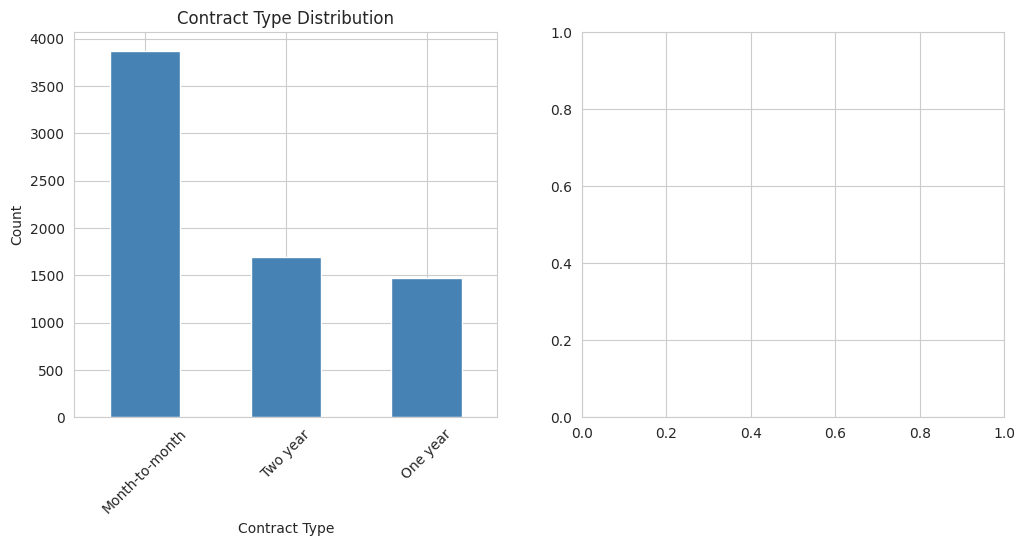

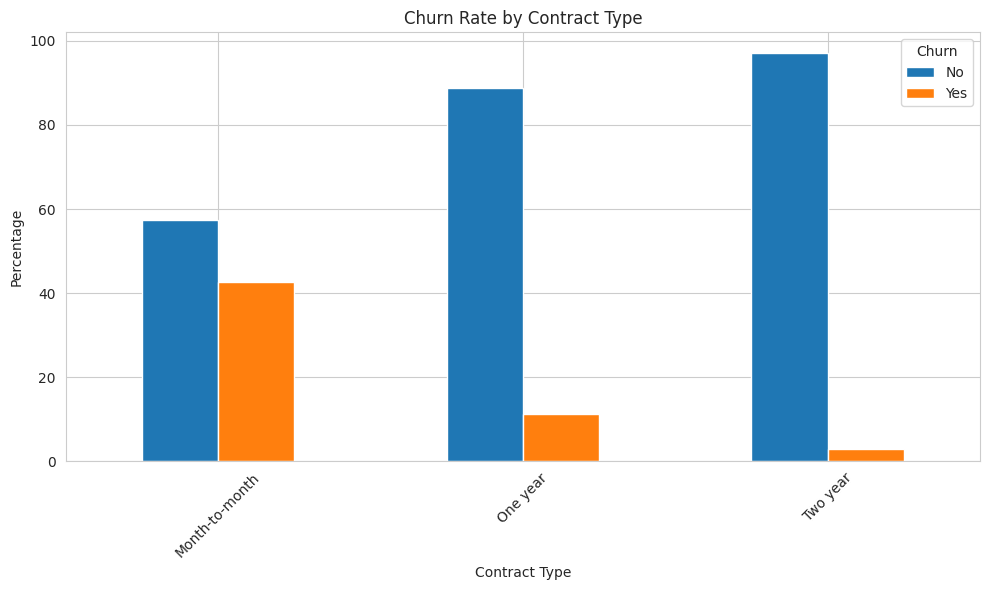

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Contract'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

SyntaxError: can't use starred expression here (397938634.py, line 9)

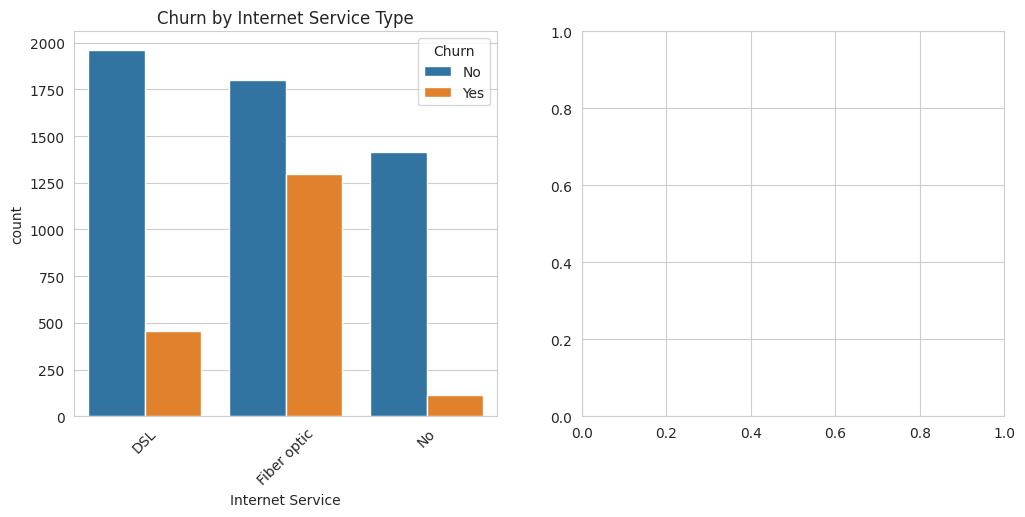

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
* 100
internet_churn['Yes'].plot(kind='bar', color='coral')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') *
100
plt.figure(figsize=(10, 6))
payment_churn['Yes'].sort_values().plot(kind='barh', color='teal')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()


## 4. Feature Correlations

In [ ]:
# Prepare numeric data
df_numeric = df.copy()
# Convert Yes/No to 1/0
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
if col in df_numeric.columns:
df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})
# Select only numeric columns
numeric_features = df_numeric.select_dtypes(include=[np.number])
# Correlation with Churn
plt.figure(figsize=(10, 8))
churn_corr = numeric_features.corr()['Churn'].sort_values(ascending=False)
churn_corr.plot(kind='barh', color='purple')
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 5. Key Insights and Findings
### High-Risk Customer Characteristics:
1. **Contract Type**: Month-to-month contracts have XX% churn rate (vs Y% for
yearly)
2. **Tenure**: Customers with <6 months tenure are high risk
3. **Charges**: Higher monthly charges correlate with higher churn
4. **Services**: Fiber optic internet users churn more than DSL
5. **Payment**: Electronic check users have higher churn
### Patterns Observed:- [Add 3-5 specific observations from your analysis]
### Recommendations for Feature Engineering:- Create 'TenureGroup' (0-12, 13-24, 25-48, 49+ months)- Flag 'HighMonthlyCharges' (>$70)- Count total services subscribed- Create 'ChargesPerService' ratio
### Questions for Next Week:- Which features should we include in the model?- How to handle categorical variables?- What about class imbalance (if churn rate is low)?

# 📊 Customer Churn Analysis – Summary Report  

**Author:** Muhammad Haseeb Bilal  
**Course:** Introduction to Applied AI  
**Date:** March 4, 2026  

---

## 1. Overview

This report presents a brief Exploratory Data Analysis (EDA) of the Telco Customer Churn dataset containing **7,043 customers** and **20 features**.

The overall churn rate is **26.54%**, meaning roughly **1 in 4 customers leave the company**.

---

## 2. Key Findings

### 🔹 Tenure
- Customers with **< 6 months tenure** show ~**54% churn**.
- Longer-tenure customers churn significantly less.
- Tenure has a strong negative correlation with churn.

### 🔹 Contract Type
- **Month-to-month:** 42.71% churn  
- **1-year:** 11.27% churn  
- **2-year:** 2.83% churn  

Contract length is one of the strongest predictors.

### 🔹 Monthly Charges
- Customers paying **>$70/month** show higher churn (~35%).
- Higher charges correlate positively with churn.

### 🔹 Internet Service
- **Fiber optic:** ~41.89% churn  
- **DSL:** ~18.96% churn  
- **No internet:** ~7.4% churn  

Fiber users churn the most.

### 🔹 Payment Method
- **Electronic check:** ~45.29% churn  
- **Automatic payments:** ~15–17% churn  

Automatic payment reduces churn risk.

---

## 3. High-Risk Customer Profile

A high-risk customer typically:
- Has a month-to-month contract  
- Has tenure < 12 months  
- Pays > $70/month  
- Uses fiber optic internet  
- Pays via electronic check  

---

## 4. Recommendations

For predictive modeling:
- Create **Tenure Groups**
- Flag **High Monthly Charges**
- Add **Total Services Count**
- Consider handling moderate class imbalance (26.54%)

---

## 5. Conclusion

Churn is strongly influenced by **contract type, tenure, payment method, and monthly charges**.  
Retaining new customers and encouraging long-term contracts may significantly reduce churn.
